In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
import numpy as np
from scipy import stats
import os
import smarts_cerebellum.globals as gl

In [14]:
atlas = 'Nettekoven2024'
rois  = gl.rois[atlas]

GM  = pd.read_csv(os.path.join(gl.baseDir, 'regression', 'summary_MNISymC_Nettekoven_2024_GM_mod_slope.tsv'), sep = '\t')
GM = GM.groupby(['subj_id', 'regionname', 'group']).mean(numeric_only=True).reset_index()

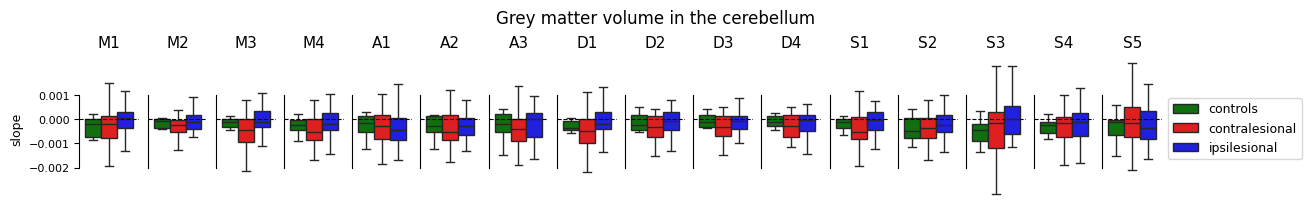

In [15]:
colours = ['green', 'r', 'blue']

fig, axs = plt.subplots(1, len(rois), figsize=(13, 2), sharex=True, sharey=True, constrained_layout=True)

for r, roi in enumerate(rois):
    ax = axs[r]
    sns.boxplot(data=GM[GM.regionname==roi], ax=ax, hue='group', y='mean', showfliers=False, legend=r==len(rois)-1, palette = colours)
    sns.despine(trim = True)
    #sns.pointplot(data=GM[GM.regionname == roi], ax = ax, y='mean', hue = 'group', errorbar='se', dodge=.55, legend=False, palette = colours)
    #sns.violinplot(data=GM[GM.regionname == roi], ax = ax, y='mean', hue = 'group', legend=False, palette = colours)
    #sns.stripplot(data=GM[GM.regionname == roi], ax = ax, y='mean', x = 'group', legend=False, palette = colours)


    ax.set_title(roi)
    ax.axhline(0, ls='--', lw=.8, color='k')
    
axs[-1].legend(loc='center left', bbox_to_anchor=(1, .5))
ax.set_xticks([])
fig.suptitle("Grey matter volume in the cerebellum")
axs[0].set_ylabel('slope')

for i in range(1, len(rois)):
    axs[i].tick_params(axis = 'y', length = 0)

fig.savefig('figure/GMV_Nettekoven2024.pdf')

plt.show()

In [16]:
for roi in rois:
    print(f'---t-tests for {roi}---')
    t_val, p_val = stats.ttest_ind(GM[(GM.group=='ipsilesional') & (GM.regionname==roi)]['mean'], GM[(GM.group=='controls') & (GM.regionname==roi)]['mean'])
    print(f'**t-test for WM {roi}: lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
    print('\n')

    t_val, p_val = stats.ttest_ind(GM[(GM.group=='contralesional') & (GM.regionname==roi)]['mean'], GM[(GM.group=='controls') & (GM.regionname==roi)]['mean'])
    print(f'**t-test for WM {roi}: non-lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
    print('\n')

    t_val, p_val = stats.ttest_rel(GM[(GM.group=='contralesional') & (GM.regionname==roi)]['mean'], GM[(GM.group=='ipsilesional') & (GM.regionname==roi)]['mean'])
    print(f'**t-test for WM {roi}: within patients, left, right hemispheres** \n t-value: {t_val} \t p-value: {p_val}')
    print('\n')

    t_val, p_val = stats.ttest_1samp(GM[(GM.group=='controls') & (GM.regionname==roi)]['mean'], popmean=0)
    print(f'**t-test against 0 for WM {roi}: controls** \n t-value: {t_val} \t p-value: {p_val}')
    print('\n')

    t_val, p_val = stats.ttest_1samp(GM[(GM.group=='contralesional') & (GM.regionname==roi)]['mean'], popmean=0)
    print(f'**t-test against 0 for WM {roi}: non-lesion** \n t-value: {t_val} \t p-value: {p_val}')
    print('\n')

    t_val, p_val = stats.ttest_1samp(GM[(GM.group=='ipsilesional') & (GM.regionname==roi)]['mean'], popmean=0)
    print(f'**t-test against 0 for WM {roi}: lesion** \n t-value: {t_val} \t p-value: {p_val}')
    print('\n')


---t-tests for M1---
**t-test for WM M1: lesion side in patients, controls** 
 t-value: -1.2772068748888932 	 p-value: 0.20780282280314208


**t-test for WM M1: non-lesion side in patients, controls** 
 t-value: -1.600162488618971 	 p-value: 0.11626386585219617


**t-test for WM M1: within patients, left, right hemispheres** 
 t-value: -1.464389373768539 	 p-value: 0.1517662823017465


**t-test against 0 for WM M1: controls** 
 t-value: 0.6190696946285842 	 p-value: 0.5484769546100734


**t-test against 0 for WM M1: non-lesion** 
 t-value: -2.2664304461946765 	 p-value: 0.029533077846055352


**t-test against 0 for WM M1: lesion** 
 t-value: -1.208353107968145 	 p-value: 0.23478917649276007


---t-tests for M2---
**t-test for WM M2: lesion side in patients, controls** 
 t-value: -0.7606056153929999 	 p-value: 0.450691756628101


**t-test for WM M2: non-lesion side in patients, controls** 
 t-value: -1.2496855600041068 	 p-value: 0.217601794477797


**t-test for WM M2: within patients, 